# Import library

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Read data

In [15]:
print('base directory is', Path.cwd())

file_path = r'..\Data\bank-additional\bank-additional\bank-additional-full.csv'

data = pd.read_csv(file_path, sep=';')
data.head()

base directory is c:\Users\armit\DSI_project\Team_ML10\code


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Data analysis

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

our business motivation is:

> **How can we increase campaign efficiency and conversion rate while reducing cost?**
 

## We first decided to Separate Pre-Campaign from Post-Contact Variables. because some of  variables are **not usable for targeting decisions** and we remove post-contact variables.

Example:

* `duration` → call duration
  You only know this *after* the call happens.
  It cannot be used to decide *who to call*.



Then to extract best leading variables, the best segmentation is:

### 🔹 A) Client Demographics (Stable Attributes)

* age
* job
* marital
* education

### 🔹 B) Financial / Credit Status

* default
* housing
* loan
* balance (if available in your version)

### 🔹 C) Campaign Interaction History (Behavioral)

* campaign
* pdays
* previous
* poutcome
* contact
* month
* day_of_week

### 🔹 D) Macroeconomic Context

* emp.var.rate
* cons.price.idx
* cons.conf.idx
* euribor3m
* nr.employed



For each variable  we are going to ask:

> Does this variable help us decide who to contact?

forexample:

> Does job affect subscription probability?







In [4]:
data['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [5]:
conversion_rate = (data['y']== 'yes').mean()*100
conversion_rate

np.float64(11.265417111780131)

In [6]:
len(data[data['y']=='yes'])

4640

In [11]:
data['as_binary'] = (data['y']=='yes')
grouped = (data.groupby('job')['as_binary'].value_counts())
grouped

job            as_binary
admin.         False        9070
               True         1352
blue-collar    False        8616
               True          638
entrepreneur   False        1332
               True          124
housemaid      False         954
               True          106
management     False        2596
               True          328
retired        False        1286
               True          434
self-employed  False        1272
               True          149
services       False        3646
               True          323
student        False         600
               True          275
technician     False        6013
               True          730
unemployed     False         870
               True          144
unknown        False         293
               True           37
Name: count, dtype: int64

To obtain informative and actionable results across job categories, we compare the success rate within each job group, using the total population of that specific category as the denominator. This allows us to estimate the conditional probability of subscription given a particular job type. Relying solely on raw frequencies is not sufficient, as larger job groups may naturally generate more subscriptions simply due to higher contact volume. Similarly, using the total number of subscribers as the denominator reflects customer composition rather than predictive strength, which can be misleading.

For example, a lower number of subscriptions among students compared to admin may simply reflect fewer contact attempts(10422 contact to admins and 875 contact to students) rather than lower interest. By calculating the success rate within each job category, we can determine whether a group truly has higher or lower conversion potential. If a segment demonstrates a relatively high success rate but has received fewer calls, this may indicate an opportunity to reallocate marketing efforts and improve overall campaign efficiency (e.g call students more).

In [12]:
grouped = (data.groupby('job')['as_binary'].
           agg(['count','mean']).
           sort_values('mean', ascending=False))


grouped['population_share'] = grouped['count']/len(data)


<Figure size 1200x600 with 0 Axes>

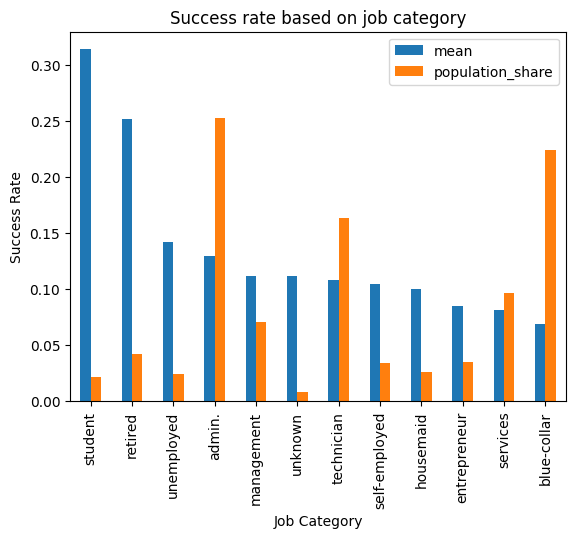

In [13]:
cols = ['mean', 'population_share']
plt.figure(figsize=(12,6))
grouped[cols].plot(kind='bar')
plt.title('Success rate based on job category')
plt.xlabel('Job Category')
plt.ylabel('Success Rate')
plt.show()


In [18]:
data['y_binary'] = (data['y'] == 'yes').astype(int)
baseline = data['y_binary'].mean()

In [19]:
def plot_categorical(ax, df, column):
    
    grouped = (
        df.groupby(column)['y_binary']
          .agg(['count','sum'])
          .rename(columns={'count':'total_calls','sum':'total_success'})
    )
    
    grouped['conversion_rate'] = grouped['total_success'] / grouped['total_calls']
    grouped['call_share'] = grouped['total_calls'] / len(df)
    
    grouped = grouped.sort_values('conversion_rate', ascending=False)
    
    x = np.arange(len(grouped.index))
    width = 0.35
    
    ax.bar(x - width/2, grouped['conversion_rate'], width, label='Conversion')
    ax.bar(x + width/2, grouped['call_share'], width, label='Call Share')
    
    ax.axhline(baseline, color='red', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(grouped.index, rotation=45)
    ax.set_title(column)

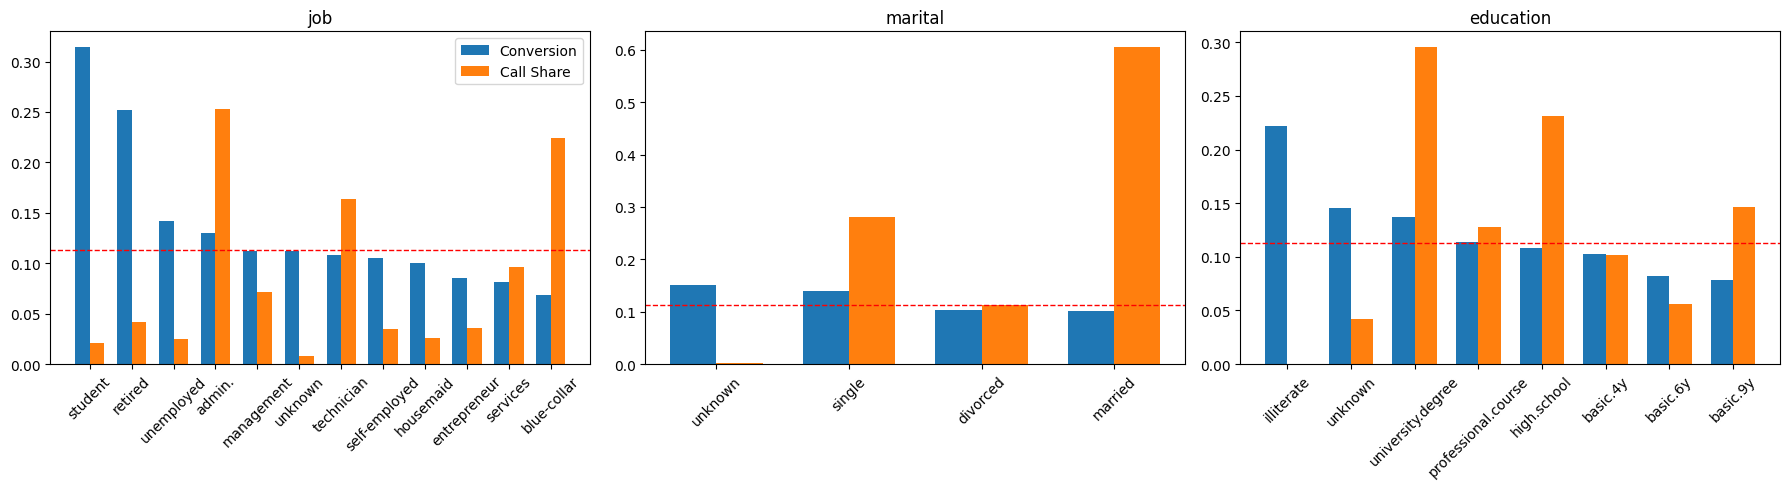

In [20]:
import numpy as np
import matplotlib.pyplot as plt

categorical_vars = ['job', 'marital', 'education']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, col in zip(axes, categorical_vars):
    plot_categorical(ax, data, col)

axes[0].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [21]:
for col in ['default','housing','loan']:
    print(data[col].value_counts())

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


# Model Development

In [22]:
def analyze_binary_var(df, column):
    
    grouped = (
        df.groupby(column)['y_binary']
          .agg(['count','sum'])
          .rename(columns={'count':'total_calls','sum':'total_success'})
    )
    
    grouped['conversion_rate'] = grouped['total_success'] / grouped['total_calls']
    grouped['call_share'] = grouped['total_calls'] / len(df)
    grouped['uplift'] = grouped['conversion_rate'] - baseline
    
    return grouped

In [23]:
for col in ['default','housing','loan']:
    print("\n", col.upper())
    print(analyze_binary_var(data, col))


 DEFAULT
         total_calls  total_success  conversion_rate  call_share    uplift
default                                                                   
no             32588           4197          0.12879    0.791201  0.016136
unknown         8597            443          0.05153    0.208726 -0.061125
yes                3              0          0.00000    0.000073 -0.112654

 HOUSING
         total_calls  total_success  conversion_rate  call_share    uplift
housing                                                                   
no             18622           2026         0.108796    0.452122 -0.003858
unknown          990            107         0.108081    0.024036 -0.004573
yes            21576           2507         0.116194    0.523842  0.003540

 LOAN
         total_calls  total_success  conversion_rate  call_share    uplift
loan                                                                      
no             33950           3850         0.113402    0.824269  0.00074

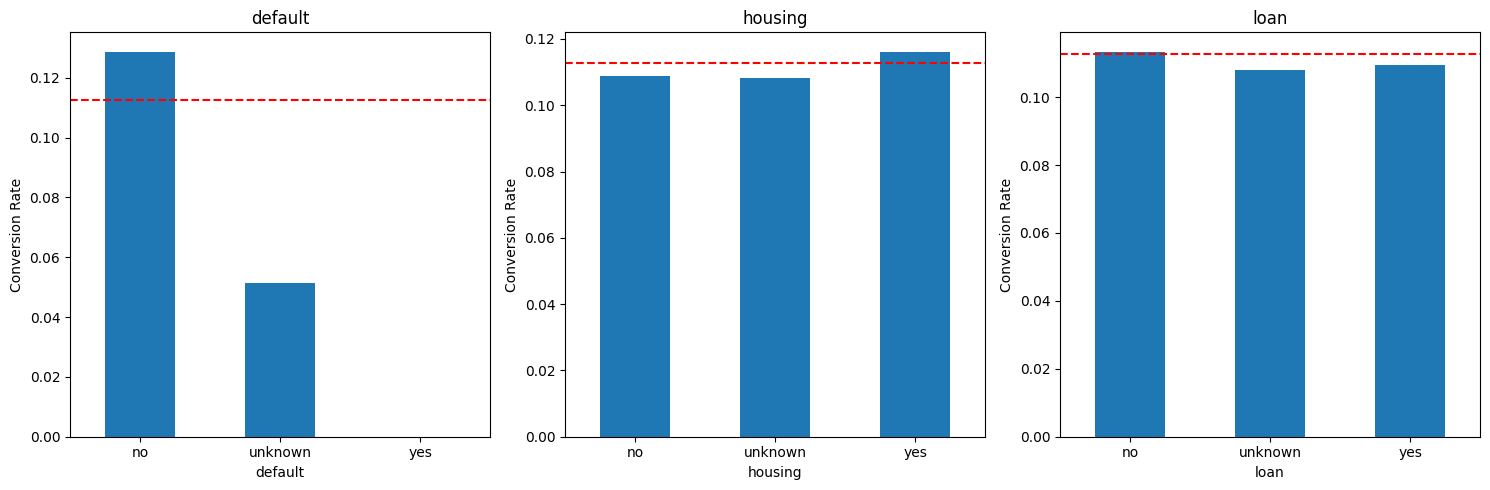

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

financial_vars = ['default','housing','loan']

for ax, col in zip(axes, financial_vars):
    
    grouped = data.groupby(col)['y_binary'].mean()
    
    grouped.plot(kind='bar', ax=ax)
    
    ax.axhline(baseline, color='red', linestyle='--')
    ax.set_title(col)
    ax.set_ylabel('Conversion Rate')
    ax.set_xticklabels(grouped.index, rotation=0)

plt.tight_layout()
plt.show()